<a href="https://colab.research.google.com/github/sreelekaa/App_Devlopment/blob/main/Market_Basket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/instacart-market-basket-analysis


In [2]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import lightgbm as lgb


In [4]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, accuracy_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMClassifier
from sklearn.ensemble import StackingClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression# Load Data
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import precision_recall_curve


In [5]:

orders = pd.read_csv("/kaggle/input/instacart-market-basket-analysis/orders.csv")
order_products = pd.read_csv("/kaggle/input/instacart-market-basket-analysis/order_products__prior.csv")
products = pd.read_csv("/kaggle/input/instacart-market-basket-analysis/products.csv")

In [6]:
orders_prior = orders[orders["eval_set"] == "prior"]
merged = pd.merge(orders_prior, order_products, on="order_id")
merged = pd.merge(merged, products, on="product_id")

In [7]:
merged.isnull().sum()

,0
order_id,0
user_id,0
eval_set,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,2078068
product_id,0
add_to_cart_order,0
reordered,0


In [8]:
merged.dropna(inplace=True)

In [9]:
merged.shape

(30356421, 13)

In [10]:
# Sample smaller dataset
sample_users = merged['user_id'].drop_duplicates().sample(n=4000, random_state=42)
sample_data = merged[merged['user_id'].isin(sample_users)]

In [11]:
from mlxtend.preprocessing import TransactionEncoder

transactions = sample_data.groupby('user_id')['product_name'].apply(list).tolist()
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_data, columns=te.columns_)


In [12]:
# Step 3: Run FP-Growth with reasonable support
frequent_itemsets = fpgrowth(basket, min_support=0.05, use_colnames=True)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")

# Step 4: Generate association rules (filter by confidence)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

# Optional: Filter rules to avoid memory bloat before sorting
rules = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.5)]
rules = rules[rules['antecedents'].apply(lambda x: len(x) <= 2)]  # Max 2 items in LHS

# Step 5: Sort by lift and show top rules
rules = rules.sort_values(by='lift', ascending=False)

print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Frequent itemsets found: 395
                                      antecedents             consequents  \
262  (Organic Yellow Onion, Organic Baby Spinach)        (Organic Garlic)   
268  (Organic Strawberries, Organic Yellow Onion)        (Organic Garlic)   
292                         (Organic Ginger Root)        (Organic Garlic)   
266        (Organic Garlic, Organic Strawberries)  (Organic Yellow Onion)   
261        (Organic Garlic, Organic Baby Spinach)  (Organic Yellow Onion)   
321               (Organic Italian Parsley Bunch)        (Organic Garlic)   
56                  (Limes, Organic Baby Spinach)        (Organic Garlic)   
59                  (Limes, Organic Strawberries)        (Organic Garlic)   
51   (Organic Hass Avocado, Organic Baby Spinach)        (Organic Garlic)   
81                  (Limes, Organic Baby Spinach)      (Organic Zucchini)   

     support  confidence      lift  
262  0.05100    0.633540  3.833830  
268  0.05075    0.611446  3.700126  
292  0.06325

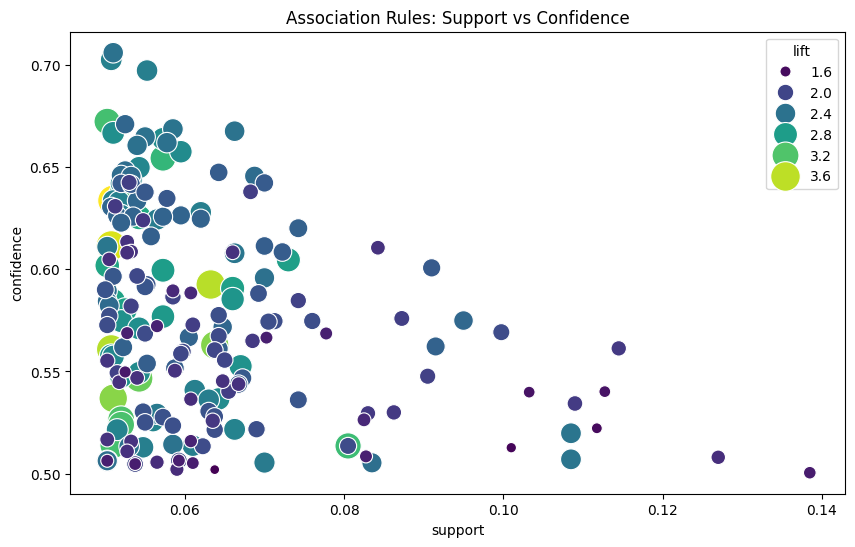

In [13]:
# Plot Rules
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x='support', y='confidence', size='lift', hue='lift', palette='viridis', sizes=(50, 500))
plt.title("Association Rules: Support vs Confidence")
plt.show()

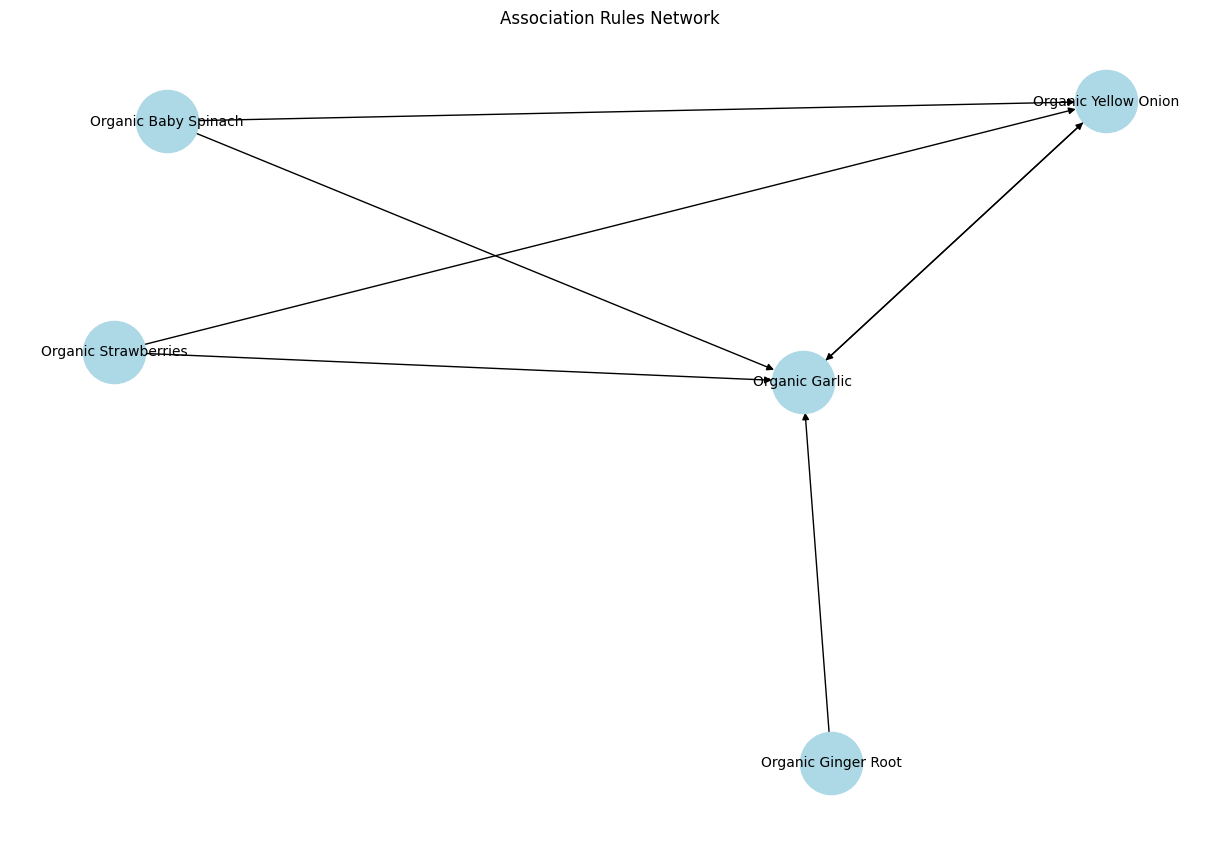

In [14]:
# 8. Network Plot
def plot_rules(rules_df):
    G = nx.DiGraph()
    for _, row in rules_df.iterrows():
        for ant in row['antecedents']:
            for cons in row['consequents']:
                G.add_edge(ant, cons, weight=row['lift'])

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=10, arrows=True)
    plt.title("Association Rules Network")
    plt.show()

plot_rules(rules.sort_values(by='lift', ascending=False).head(5))

In [15]:
# Recommendation Function
def recommend(product_name):
    product_name = product_name.strip()
    filtered = rules[rules['antecedents'].apply(lambda x: product_name in list(x))]
    if filtered.empty:
        return pd.DataFrame()
    return filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

print(recommend("Organic Strawberries"))

                                        antecedents               consequents  \
268    (Organic Strawberries, Organic Yellow Onion)          (Organic Garlic)   
266          (Organic Garlic, Organic Strawberries)    (Organic Yellow Onion)   
59                    (Limes, Organic Strawberries)          (Organic Garlic)   
191             (Organic Strawberries, Large Lemon)                   (Limes)   
52           (Organic Garlic, Organic Strawberries)    (Organic Hass Avocado)   
239     (Organic Strawberries, Organic Raspberries)    (Organic Hass Avocado)   
60           (Organic Garlic, Organic Strawberries)                   (Limes)   
85         (Organic Strawberries, Organic Zucchini)    (Organic Baby Spinach)   
189                   (Limes, Organic Strawberries)             (Large Lemon)   
64           (Organic Garlic, Organic Strawberries)    (Organic Baby Spinach)   
8      (Organic Strawberries, Organic Baby Spinach)    (Organic Hass Avocado)   
17                    (Limes

In [16]:
# Customer Segmentation
user_product = sample_data.groupby(['user_id', 'product_name']).size().unstack().fillna(0)
user_product_normalized = user_product.div(user_product.sum(axis=1), axis=0).fillna(0)

pca = PCA(n_components=2)
user_pca = pca.fit_transform(user_product_normalized)
kmeans = KMeans(n_clusters=2, random_state=42)
user_segments = kmeans.fit_predict(user_product_normalized)

sil_score = silhouette_score(user_product_normalized, user_segments)
print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.238


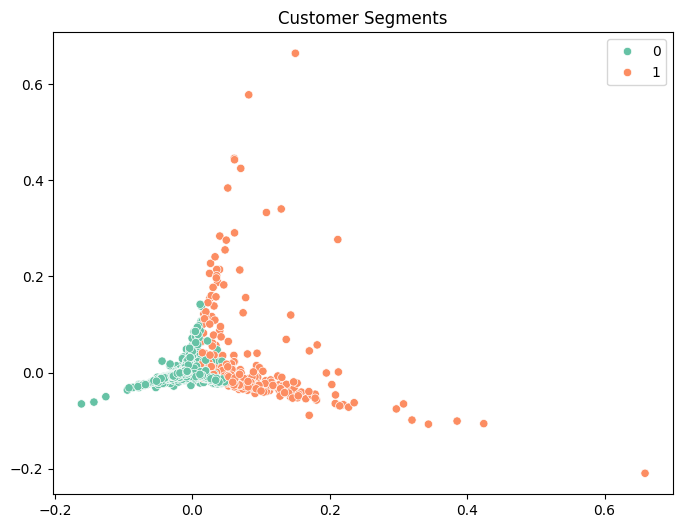

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=user_pca[:, 0], y=user_pca[:, 1], hue=user_segments, palette="Set2")
plt.title("Customer Segments")
plt.show()


In [18]:
# Encode product_id
le = LabelEncoder()
merged['product_id'] = le.fit_transform(merged['product_id'].astype(str))


In [19]:
# Sample 10,000 unique users for analysis
sample_users = merged['user_id'].drop_duplicates().sample(n=10000, random_state=42)
merged_sample = merged[merged['user_id'].isin(sample_users)]


In [20]:
merged_sample.sort_values(['user_id', 'product_id', 'order_number'], inplace=True)

/tmp/ipython-input-20-49300976.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_sample.sort_values(['user_id', 'product_id', 'order_number'], inplace=True)


In [21]:
# ------------------------
# Feature Engineering
# ------------------------
merged_sample.sort_values(['user_id', 'product_id', 'order_number'], inplace=True)

merged_sample['user_total_orders'] = merged_sample.groupby('user_id')['order_number'].transform('max')
merged_sample['basket_size'] = merged_sample.groupby('order_id')['product_id'].transform('count')
merged_sample['product_rank'] = merged_sample['product_id'].map(merged_sample['product_id'].value_counts().rank(method='min', ascending=False))

last_order = merged_sample.groupby(['user_id', 'product_id'])['order_number'].transform(lambda x: x.shift().fillna(0))
merged_sample['user_product_last_order_gap'] = merged_sample['order_number'] - last_order

user_recent = (
    merged_sample.sort_values(['user_id', 'order_number'])
    .groupby('user_id')['reordered']
    .rolling(5, min_periods=1).mean().reset_index(level=0, drop=True)
)
merged_sample['user_recent_reorder_ratio'] = user_recent.values

reorder_counts = (
    merged_sample.groupby(['user_id', 'product_id'])['reordered']
    .sum().reset_index()
)
reorder_counts['frequent_product_for_user'] = (reorder_counts['reordered'] >= 3).astype(int)
merged_sample = pd.merge(
    merged_sample,
    reorder_counts[['user_id', 'product_id', 'frequent_product_for_user']],
    on=['user_id', 'product_id'],
    how='left'
)

dow_stats = merged_sample.groupby('user_id')['order_dow'].agg(['nunique', 'count']).reset_index()
dow_stats['order_dow_consistency'] = 1 - (dow_stats['nunique'] / dow_stats['count'])
merged_sample = pd.merge(
    merged_sample,
    dow_stats[['user_id', 'order_dow_consistency']],
    on='user_id',
    how='left'
)

product_pop = merged_sample['product_id'].value_counts().reset_index()
product_pop.columns = ['product_id', 'product_order_count']
merged_sample = pd.merge(merged_sample, product_pop, on='product_id', how='left')

merged_sample['recency_score'] = 1 / (merged_sample['user_product_last_order_gap'] + 1)
merged_sample['normalized_cart_position'] = merged_sample['add_to_cart_order'] / merged_sample['basket_size']
merged_sample['rolling_user_reorder'] = (
    merged_sample.groupby('user_id')['reordered']
    .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)
user_product_order_count = merged_sample.groupby(['user_id', 'product_id'])['order_id'].transform('count')
merged_sample['user_product_order_rate'] = user_product_order_count / merged_sample['user_total_orders']

# ✅ New Features Added:
merged_sample['user_reorder_ratio'] = (
    merged_sample.groupby('user_id')['reordered'].transform('mean')
)
merged_sample['product_reorder_ratio'] = (
    merged_sample.groupby('product_id')['reordered'].transform('mean')
)
merged_sample['user_product_reorder_rate'] = (
    merged_sample.groupby(['user_id', 'product_id'])['reordered'].transform('mean')
)
merged_sample['reordered_last_order'] = (
    merged_sample.groupby(['user_id', 'product_id'])['reordered'].shift(1).fillna(0)
)


/tmp/ipython-input-21-2635462300.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_sample.sort_values(['user_id', 'product_id', 'order_number'], inplace=True)
/tmp/ipython-input-21-2635462300.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_sample['user_total_orders'] = merged_sample.groupby('user_id')['order_number'].transform('max')
/tmp/ipython-input-21-2635462300.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

In [22]:
features = [
    'add_to_cart_order', 'days_since_prior_order', 'order_dow', 'user_total_orders',
    'basket_size', 'product_rank', 'user_product_last_order_gap', 'user_recent_reorder_ratio',
    'frequent_product_for_user', 'order_dow_consistency', 'product_order_count',
    'recency_score', 'normalized_cart_position', 'rolling_user_reorder', 'user_product_order_rate',
    'user_reorder_ratio', 'product_reorder_ratio', 'user_product_reorder_rate', 'reordered_last_order'
]


In [23]:
from catboost import CatBoostClassifier
model_data = merged_sample[features + ['reordered']].dropna()
X = model_data[features]
y = model_data['reordered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ------------------------
# Stacking Model
# ------------------------
cat = CatBoostClassifier(verbose=0, iterations=800, learning_rate=0.02, depth=10, random_seed=42)
lgb = LGBMClassifier(n_estimators=800, learning_rate=0.02, max_depth=10, random_state=42)
lr = LogisticRegression(max_iter=500, random_state=42)

stacked_model = StackingClassifier(
    estimators=[('cat', cat), ('lgb', lgb)],
    final_estimator=lr,
    cv=5,
    passthrough=True
)

stacked_model.fit(X_train, y_train)

# ------------------------
# Evaluation
# ------------------------
y_proba = stacked_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_thresh = thresholds[np.argmax(f1_scores)]

y_pred = (y_proba >= best_thresh).astype(int)

print(f"Best Threshold: {best_thresh:.2f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred)*100:.2f}%")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba)*100:.2f}%")


[LightGBM] [Info] Number of positive: 742360, number of negative: 432170
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2331
[LightGBM] [Info] Number of data points in the train set: 1174530, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.632049 -> initscore=0.541015
[LightGBM] [Info] Start training from score 0.541015


/usr/local/lib/python3.11/dist-packages/sklearn/utils/_tags.py:354: DeprecationWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/_tags.py:354: DeprecationWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__

[LightGBM] [Info] Number of positive: 593888, number of negative: 345736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.104859 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2331
[LightGBM] [Info] Number of data points in the train set: 939624, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.632049 -> initscore=0.541015
[LightGBM] [Info] Start training from score 0.541015


/usr/local/lib/python3.11/dist-packages/sklearn/utils/_tags.py:354: DeprecationWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/_tags.py:354: DeprecationWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__

[LightGBM] [Info] Number of positive: 593888, number of negative: 345736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2327
[LightGBM] [Info] Number of data points in the train set: 939624, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.632049 -> initscore=0.541015
[LightGBM] [Info] Start training from score 0.541015


...

[LightGBM] [Info] Number of positive: 593888, number of negative: 345736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2331
[LightGBM] [Info] Number of data points in the train set: 939624, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.632049 -> initscore=0.541015
[LightGBM] [Info] Start training from score 0.541015


/usr/local/lib/python3.11/dist-packages/sklearn/utils/_tags.py:354: DeprecationWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/_tags.py:354: DeprecationWarning: The LGBMClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__

[LightGBM] [Info] Number of positive: 593888, number of negative: 345736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058190 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2329
[LightGBM] [Info] Number of data points in the train set: 939624, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.632049 -> initscore=0.541015
[LightGBM] [Info] Start training from score 0.541015


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best Threshold: 0.49
Accuracy: 91.16%
F1 Score: 93.08%
ROC AUC: 97.63%


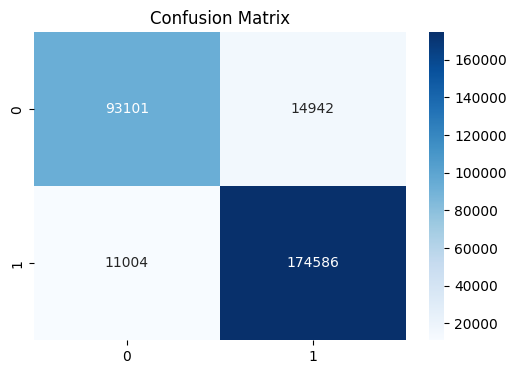

In [24]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

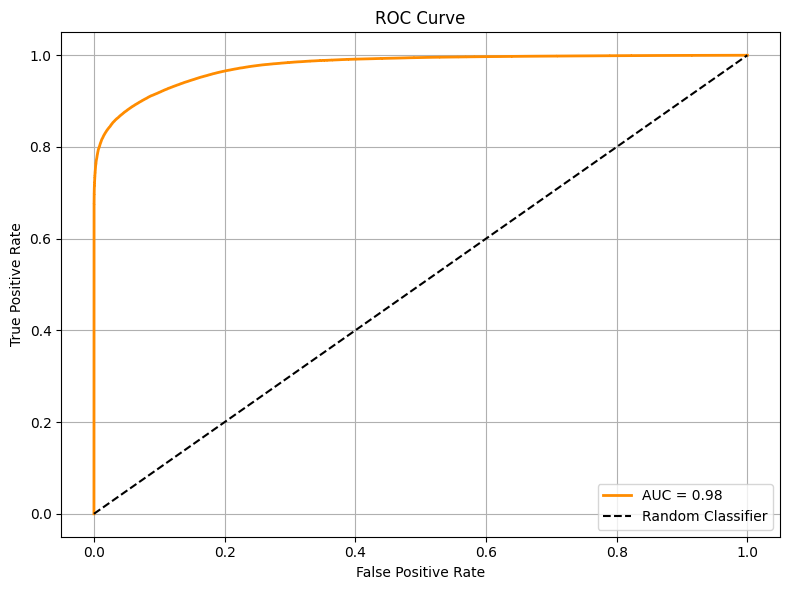

In [25]:
# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, y_proba)

# Compute ROC curve points
fpr, tpr, _ = roc_curve(y_test, y_proba)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
pip install prophet


INFO:prophet:n_changepoints greater than number of observations. Using 11.
DEBUG:cmdstanpy:input tempfile: /tmp/tmphh947lgs/7d31lpre.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmphh947lgs/huh296o5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=35664', 'data', 'file=/tmp/tmphh947lgs/7d31lpre.json', 'init=/tmp/tmphh947lgs/huh296o5.json', 'output', 'file=/tmp/tmphh947lgs/prophet_model569hx3zj/prophet_model-20250627152901.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:29:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:29:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


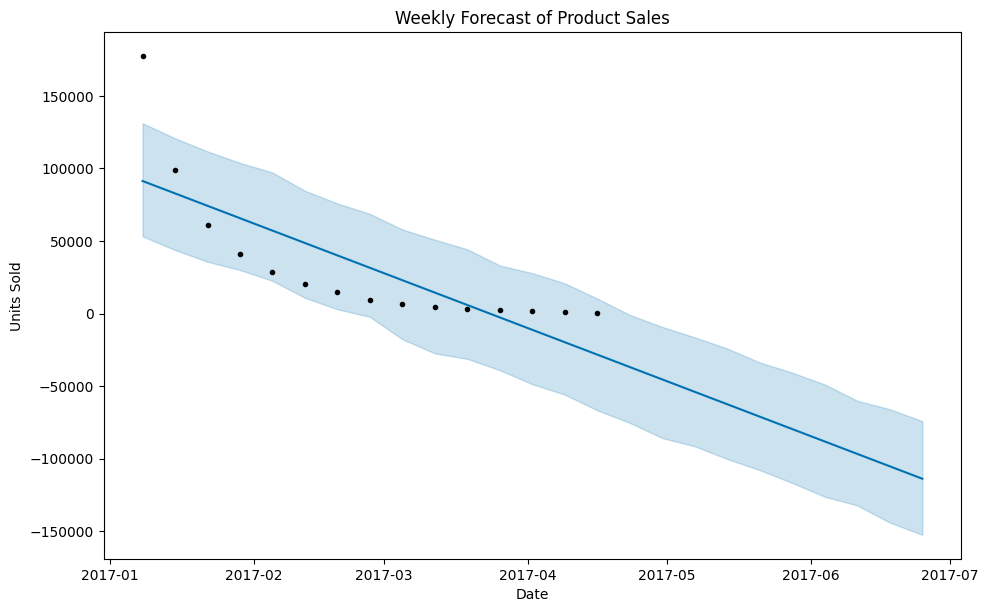

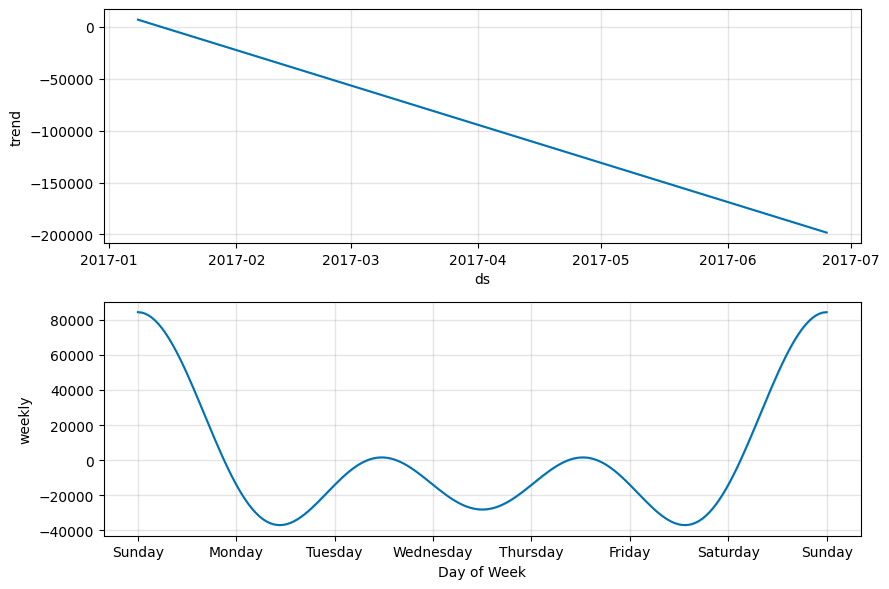

In [27]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# Simulate date from order_number
orders['order_date'] = pd.to_datetime("2017-01-01") + pd.to_timedelta(orders['order_number'], unit='D')

# Merge product info with order dates
merged = pd.merge(order_products, orders[['order_id', 'order_date']], on='order_id')

# ------------------------
product_id = 24852  # Banana in Instacart dataset
product_sales = merged[merged['product_id'] == product_id]

# ------------------------
# Aggregate Daily Sales
# ------------------------
daily_sales = product_sales.groupby('order_date').size().reset_index(name='y')
daily_sales.columns = ['ds', 'y']  # Prophet requires columns: ds (date), y (value)

# ------------------------
# Fill Missing Dates and Resample to Weekly Sales
# ------------------------
daily_sales = daily_sales.set_index('ds').asfreq('D').fillna(0)  # fill missing days with 0 sales
weekly_sales = daily_sales.resample('W').sum().reset_index()

# ------------------------
# Prophet Forecasting Model
# ------------------------
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05  # adjust sensitivity to trend changes
)
model.fit(weekly_sales)

# ------------------------
# Forecast Next 10 Weeks
# ------------------------
future = model.make_future_dataframe(periods=10, freq='W')
forecast = model.predict(future)

# ------------------------
# Plot Forecast
# ------------------------
fig1 = model.plot(forecast)
plt.title("Weekly Forecast of Product Sales")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.grid()
plt.show()

# ------------------------
# Plot Forecast Components (Trend, Seasonality)
# ------------------------
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

In [28]:
def get_promotion_pricing_suggestions(rules_df, min_lift=1.2, min_confidence=0.5):
    """
    Suggest product pairs for promotions based on association rules.

    Parameters:
        rules_df (DataFrame): Output of `association_rules()` function.
        min_lift (float): Minimum lift value to consider strong association.
        min_confidence (float): Minimum confidence value.

    Returns:
        DataFrame: Filtered suggestions suitable for promotions.
    """
    # Filter rules for strong associations
    suggestions = rules_df[
        (rules_df['lift'] >= min_lift) &
        (rules_df['confidence'] >= min_confidence)
    ][['antecedents', 'consequents', 'support', 'confidence', 'lift']]

    return suggestions.sort_values(by='lift', ascending=False).reset_index(drop=True)


In [29]:
promotion_suggestions = get_promotion_pricing_suggestions(rules)
print(promotion_suggestions)

                                      antecedents             consequents  \
0    (Organic Yellow Onion, Organic Baby Spinach)        (Organic Garlic)   
1    (Organic Strawberries, Organic Yellow Onion)        (Organic Garlic)   
2                           (Organic Ginger Root)        (Organic Garlic)   
3          (Organic Garlic, Organic Strawberries)  (Organic Yellow Onion)   
4          (Organic Garlic, Organic Baby Spinach)  (Organic Yellow Onion)   
..                                            ...                     ...   
191                                 (Large Lemon)                (Banana)   
192                             (Organic Avocado)                (Banana)   
193                                       (Limes)                (Banana)   
194                                (Strawberries)                (Banana)   
195  (Organic Strawberries, Organic Baby Spinach)                (Banana)   

     support  confidence      lift  
0    0.05100    0.633540  3.833830  
1